In [ ]:
# Quantum Random Number Generator (QDK + Python)

This notebook demonstrates how to generate true random numbers using quantum computing principles (Q#) and visualize the results using Python.

Steps:
1. Install dependencies
2. Initialize quantum runtime
3. Generate random bits
4. Build random numbers
5. Visualize distribution


In [ ]:
%pip install "qdk[jupyter]"
%pip install matplotlib

In [ ]:
import qsharp
import matplotlib.pyplot as plt


In [15]:
%%qsharp

operation GenerateRandomBit() : Result {
    use q = Qubit();
    H(q);
    let result = M(q);
    Reset(q);
    return result;
}

In [16]:
qsharp.eval("GenerateRandomBit()")

One

In [17]:
[qsharp.eval("GenerateRandomBit()") for _ in range(10)]

[Zero, One, Zero, Zero, Zero, Zero, One, Zero, Zero, One]

In [18]:
%%qsharp

import Std.Convert.*;
import Std.Math.*;

operation GenerateRandomNumberInRange(max : Int) : Int {
    mutable bits = [];
    let nBits = BitSizeI(max);

    for idxBit in 1..nBits {
        bits += [GenerateRandomBit()];
    }

    let sample = ResultArrayAsInt(bits);

    return sample > max ? GenerateRandomNumberInRange(max) | sample;
}


In [19]:
qsharp.eval("GenerateRandomNumberInRange(100)")

67

In [20]:
[qsharp.eval("GenerateRandomNumberInRange(100)") for _ in range(10)]

[25, 1, 11, 13, 69, 48, 17, 93, 29, 6]

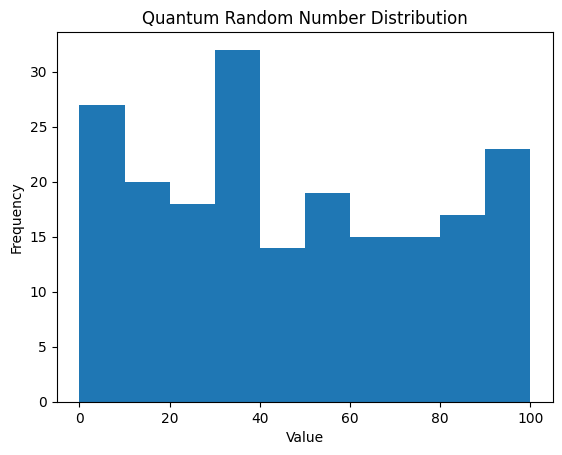

In [23]:
import matplotlib.pyplot as plt

results = [qsharp.eval("GenerateRandomNumberInRange(100)") for _ in range(200)]

plt.hist(results, bins=10)
plt.title("Quantum Random Number Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()